Loaded shape: (50000, 2)
Reviews with uppercase: 49780 out of 50000


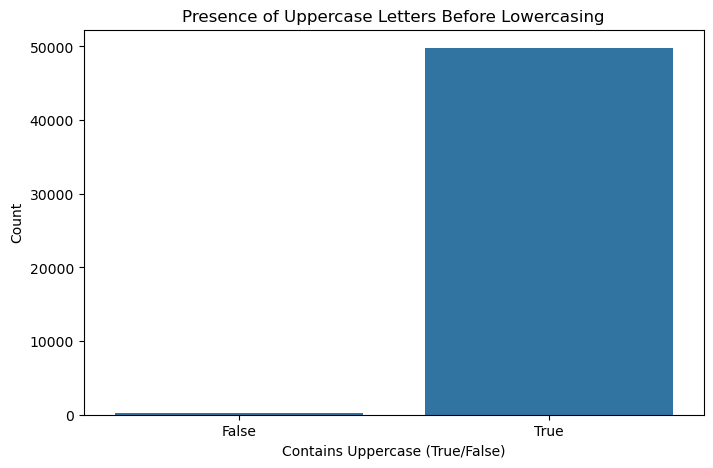

Reviews with uppercase after: 0 out of 50000
Sample before:
 one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me abo...
Sample after:
 one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me abo...


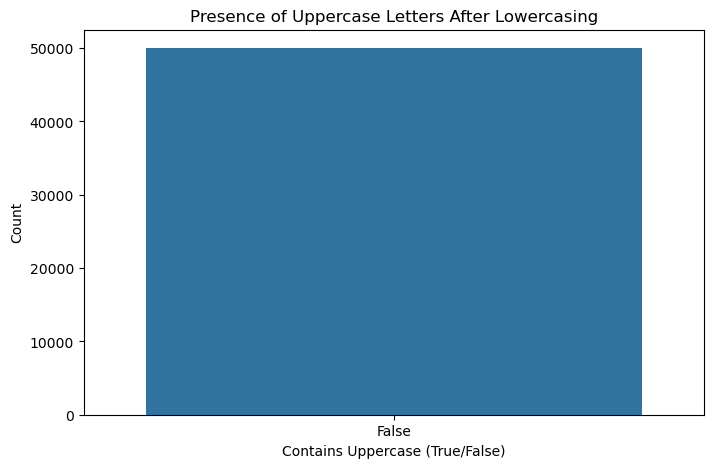

Saved to: lowercased.csv


In [4]:
# lowercasing.py
# IT2011 Group Assignment - Progress Review I: Lowercasing Preprocessing
# Contributor: [Your Member ID, e.g., IT24100109] (replacing Spell Checking)
# Description: Converts all text to lowercase for uniformity in the IMDB Dataset.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create processed_data directory
os.makedirs('../results/outputs/', exist_ok=True)

# Load data from previous step (ngrams_extracted.csv)
try:
    df = pd.read_csv('../results/outputs/missing_handled.csv')
    print("Loaded shape:", df.shape)
except FileNotFoundError:
    print("Error: ngrams_extracted.csv not found. Ensure the previous pipeline step (N-grams Extraction) is completed.")
    exit(1)

# Before lowercasing: Check case distribution
df['sample_text'] = df['review'].apply(lambda x: x[:50])  # Take first 50 chars as sample
df['has_upper'] = df['review'].apply(lambda x: any(c.isupper() for c in x))
upper_count = df['has_upper'].sum()
total_count = len(df)
print(f"Reviews with uppercase: {upper_count} out of {total_count}")

# EDA Visualization: Bar plot of reviews with/without uppercase
plt.figure(figsize=(8, 5))
sns.countplot(x='has_upper', data=df)
plt.title("Presence of Uppercase Letters Before Lowercasing")
plt.xlabel("Contains Uppercase (True/False)")
plt.ylabel("Count")
plt.show()

# Apply lowercasing
df['review'] = df['review'].apply(lambda x: x.lower())

# After lowercasing: Verify no uppercase
df['has_upper_after'] = df['review'].apply(lambda x: any(c.isupper() for c in x))
upper_count_after = df['has_upper_after'].sum()
print(f"Reviews with uppercase after: {upper_count_after} out of {total_count}")

# EDA Visualization: Sample comparison
print("Sample before:\n", df['review'].iloc[0][:200] + "...")
print("Sample after:\n", df['review'].iloc[0][:200] + "...")

# EDA Visualization: Bar plot after lowercasing
plt.figure(figsize=(8, 5))
sns.countplot(x='has_upper_after', data=df)
plt.title("Presence of Uppercase Letters After Lowercasing")
plt.xlabel("Contains Uppercase (True/False)")
plt.ylabel("Count")
plt.show()

# Interpretation: Before lowercasing, a significant portion of reviews contain uppercase (e.g., titles or emphasis). After lowercasing, all text is uniform, with zero uppercase instances, reducing vocabulary size and improving model consistency.

# Save processed data
df = df.drop(['sample_text', 'has_upper', 'has_upper_after', 'review'], axis=1)
df.to_csv('../results/outputs/lowercased.csv', index=False)
print("Saved to: lowercased.csv")